  # Importação de bibliotecas

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, classification_report

# Importação do dataset

In [4]:
# https://www.kaggle.com/datasets/payaldhokane/deepfake-and-synthetic-media-detection-dataset
dados = pd.read_csv('deepfake_detection_metadata_dataset.csv')
dados.head()

,media_id,media_type,content_category,face_count,audio_present,lip_sync_score,visual_artifacts_score,compression_level,lighting_inconsistency_score,source_platform,generation_method,label
0,1,Image,News,2,Yes,0.76,0.24,0.06,0.23,Facebook,NaN,Real
1,2,Video,News,3,Yes,0.01,0.82,0.62,0.98,Instagram,Diffusion,Fake
2,3,Video,Political Speech,3,No,0.20,0.66,0.23,0.77,News Website,GAN,Fake
3,4,Image,Social Media,4,Yes,0.81,0.19,0.68,0.29,YouTube,NaN,Real
4,5,Video,Interview,1,Yes,0.98,0.00,0.23,0.17,Twitter,NaN,Real


# Limpeza e conversão dos dados

In [5]:
print("--- Informações do Dataset ---")
print(dados.info())
print("\n--- Valores nulos por coluna ---")
print(dados.isnull().sum())

# Remoção de dados que podem causar vazamento
dados = dados.drop(['media_id', 'generation_method'], axis=1)
# Conversão de texto em número
dados['label'] = dados['label'].map({'Real': 0, 'Fake': 1})

dados.head() # verificar

--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   media_id                      1000 non-null   int64  
 1   media_type                    1000 non-null   object 
 2   content_category              1000 non-null   object 
 3   face_count                    1000 non-null   int64  
 4   audio_present                 1000 non-null   object 
 5   lip_sync_score                1000 non-null   float64
 6   visual_artifacts_score        1000 non-null   float64
 7   compression_level             1000 non-null   float64
 8   lighting_inconsistency_score  1000 non-null   float64
 9   source_platform               1000 non-null   object 
 10  generation_method             499 non-null    object 
 11  label                         1000 non-null   object 
dtypes: float64(4), int64(2), object(

,media_type,content_category,face_count,audio_present,lip_sync_score,visual_artifacts_score,compression_level,lighting_inconsistency_score,source_platform,label
0,Image,News,2,Yes,0.76,0.24,0.06,0.23,Facebook,0
1,Video,News,3,Yes,0.01,0.82,0.62,0.98,Instagram,1
2,Video,Political Speech,3,No,0.20,0.66,0.23,0.77,News Website,1
3,Image,Social Media,4,Yes,0.81,0.19,0.68,0.29,YouTube,0
4,Video,Interview,1,Yes,0.98,0.00,0.23,0.17,Twitter,0


In [6]:
# Convertendo as colunas de texto em numéricas
colunas_categoricas = ['media_type', 'content_category', 'audio_present', 'source_platform']
# O drop_first=True remove a primeira categoria de cada coluna para evitar redundância na rede neural (eficiente para reduzir o tamanho total dela)
dados = pd.get_dummies(dados, columns=colunas_categoricas, drop_first=True)

# Garante que todos os dados fiquem em formato numérico padrão (float) para o TensorFlow
dados = dados.astype(float)

# Separa as entradas da saída desejada
X = dados.drop('label', axis=1).values
y = dados['label'].values

# Verificando o formato final após as transformações
print(f"Formato de X (Entradas): {X.shape}")
print(f"Formato de y (Saída): {y.shape}")

Formato de X (Entradas): (1000, 17)
Formato de y (Saída): (1000,)


# Separando os dados e Padronizando

In [7]:
# Dividindo os dados
# O stratify=y serve para que a proporção de Reais e Fakes seja a mesma no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

# O 'fit_transform' no treino calcula a média/desvio e já aplica a transformação
X_train_padronizado = scaler.fit_transform(X_train)

# O 'transform' no teste apenas aplica a mesma escala aprendida no treino
X_test_padronizado = scaler.transform(X_test)

print("Dados separados e padronizados:")
print(f"Qtd de dados para o Treino (Estudo): {X_train_padronizado.shape[0]}")
print(f"Qtd de dados para o Teste (Prova): {X_test_padronizado.shape[0]}")

Dados separados e padronizados:
Qtd de dados para o Treino (Estudo): 800
Qtd de dados para o Teste (Prova): 200


# Criando a Arquitetura da Rede Neural (MLP)

In [9]:
modelo = tf.keras.models.Sequential()

# 1ª Camada Oculta: 64 neurônios, função ReLU, recebendo as 17 características de entrada
modelo.add(tf.keras.layers.Dense(units=64, activation='relu', input_shape=(X_train_padronizado.shape[1],)))
# 2ª Camada Oculta: 32 neurônios, função ReLU (ajuda a aprender padrões mais profundos)
modelo.add(tf.keras.layers.Dense(units=32, activation='relu'))
# Camada de Saída: 1 neurônio, função Sigmoid (para dar uma resposta entre 0 e 1)
modelo.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

# Compilanmdo e treinando o modelo

In [10]:
# Compilando o modelo
# learning_rate é o tamanho do 'passo' que a IA dá para aprender. 0.001 é um padrão comumm, 0.002 tbm
otimizador = tf.keras.optimizers.Adam(learning_rate=0.001)

# 'binary_crossentropy' porque é um problema de 2 classes (0 ou 1)
# 'accuracy' para ver a porcentagem de acertos
modelo.compile(optimizer=otimizador, loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento do modelo
historico = modelo.fit(X_train_padronizado, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5688 - loss: 0.6836 - val_accuracy: 0.8250 - val_loss: 0.5835
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9172 - loss: 0.4976 - val_accuracy: 0.9688 - val_loss: 0.4118
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9875 - loss: 0.3111 - val_accuracy: 0.9937 - val_loss: 0.2359
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9984 - loss: 0.1565 - val_accuracy: 1.0000 - val_loss: 0.1239
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9984 - loss: 0.0742 - val_accuracy: 1.0000 - val_loss: 0.0705
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0401 - val_accuracy: 1.0000 - val_loss: 0.0473
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0252 - val_accuracy: 1.0000 - val_loss: 0.0345
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0174 - val_accuracy: 1.0000

# Resultados do treino

In [14]:
# Função para plotar os gráficos
def plotar_aprendizado(historico, usar_log=False):
    plt.figure(figsize=(12, 5))

    # Gráfico 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(historico.history['loss'], label='Treino')
    plt.plot(historico.history['val_loss'], label='Validação')
    plt.title('Função de Perda (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Erro')
    if usar_log:
        plt.yscale('log')
    plt.legend()
    plt.grid(True)

    # Gráfico 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(historico.history['accuracy'], label='Treino')
    plt.plot(historico.history['val_accuracy'], label='Validação')
    plt.title('Acurácia (Acertos)')
    plt.xlabel('Épocas')
    plt.ylabel('Taxa de Acerto')
    if usar_log:
        plt.yscale('log')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

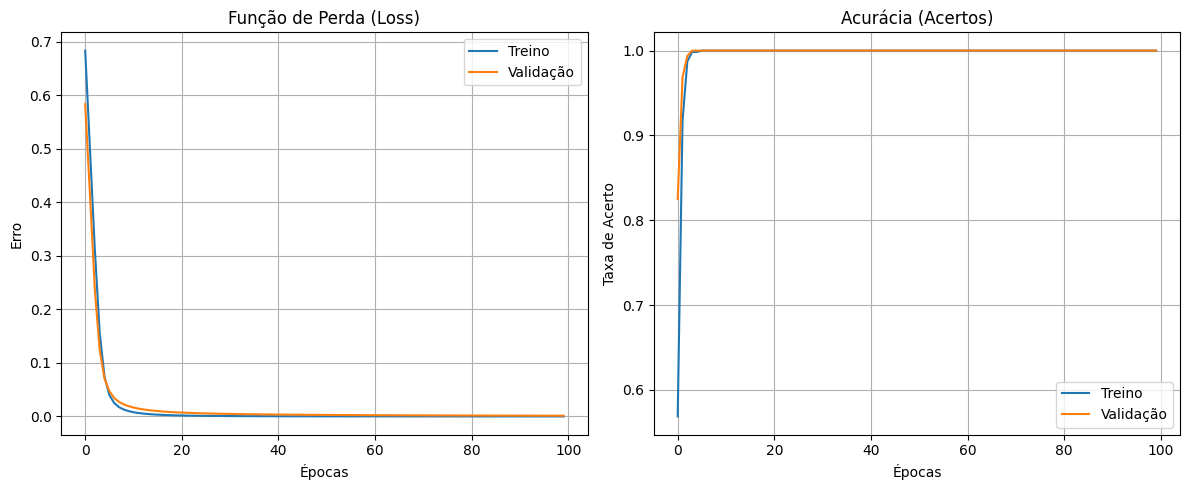

In [15]:
plotar_aprendizado(historico)

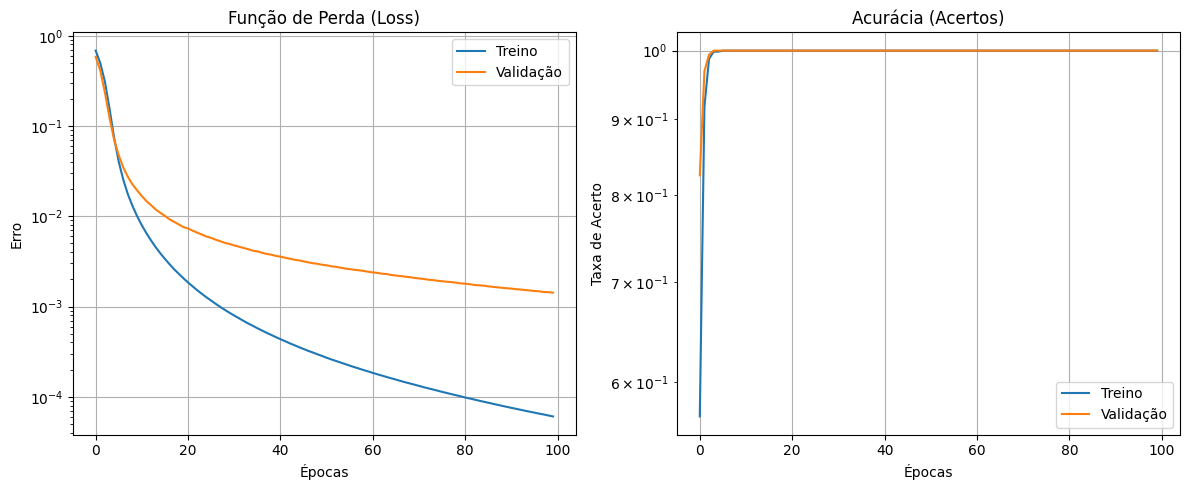

In [16]:
plotar_aprendizado(historico, usar_log=True)

# Avaliando o modelo no conjunto de Teste


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Acurácia nos dados de teste: 99.50%

Relatório de Classificação:
              precision    recall  f1-score   support

    Real (0)       0.99      1.00      1.00       100
    Fake (1)       1.00      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



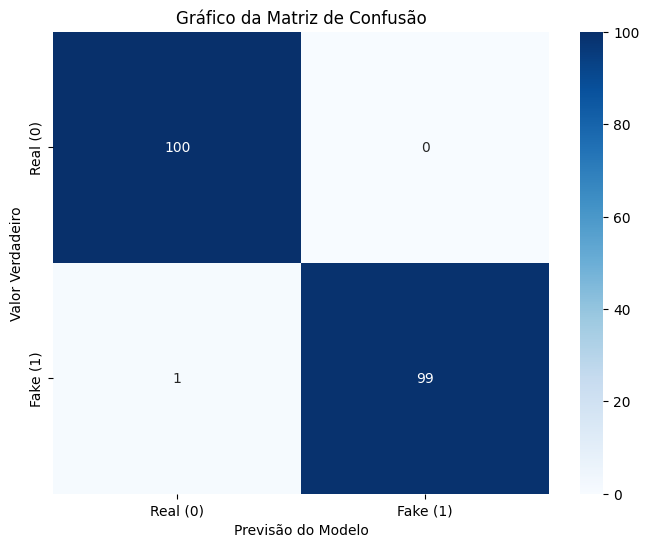

In [19]:
# Pedir para a IA fazer as previsões usando os dados da "prova"
previsoes_probabilidade = modelo.predict(X_test_padronizado)

# Como a última camada usa 'sigmoid', a saída é uma probabilidade de 0 a 1
# Arredondando: se for > 0.5, consideramos fake (1). Se for <= 0.5, real (0).
previsoes_finais = (previsoes_probabilidade > 0.5).astype(int)

# Calculando as métricas
acuracia = accuracy_score(y_test, previsoes_finais)
matriz_confusao = confusion_matrix(y_test, previsoes_finais)

# Imprimindo os resultados em texto
print(f"Acurácia nos dados de teste: {acuracia * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(y_test, previsoes_finais, target_names=['Real (0)', 'Fake (1)']))

# --- Plotando a Matriz de Confusão Visual ---
plt.figure(figsize=(8, 6))

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])

plt.title('Gráfico da Matriz de Confusão')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Verdadeiro')
plt.show()